# 🌲 Forest Cover Type Classification
## Introduction

This project focuses on classifying forest cover types based on cartographic and environmental features from the UCI Covertype dataset. The dataset contains measurements such as elevation, slope, soil type, and wilderness area, which together help predict the dominant type of forest cover in a given area.

Objectives:

- Understand the relationship between environmental and topographic features influencing forest cover types.

- Build and compare tree-based classification models (e.g., Random Forest and XGBoost) to predict forest cover type.

- Evaluate model performance using multi-class metrics and visualize confusion matrices and feature importance for deeper insights.

- Apply data preprocessing, feature scaling, and hyperparameter tuning to enhance model accuracy and robustness.

### ❶ import Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### ❷ Loading Data

In [4]:
df = pd.read_csv("/kaggle/input/forest-cover-type-dataset/covtype.csv")
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


### ❸ Exploring Data

In [5]:
df['Cover_Type'].value_counts()

Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64

In [6]:
df['Cover_Type'].unique()

array([5, 2, 1, 7, 3, 6, 4])

In [7]:
df.shape

(581012, 55)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [9]:
df.isna().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


In [5]:
columns = df.columns.tolist()

features = [x for x in columns if x != 'Cover_Type']

X = df[features]
y = df['Cover_Type']

In [6]:
binary_cols = [col for col in features if X[col].nunique() == 2]
non_binary_cols = [col for col in features if X[col].nunique() > 2]
print(f"Number of binary columns: {len(binary_cols)}")
print(f"Number of non-binary columns: {len(non_binary_cols)}")

Number of binary columns: 44
Number of non-binary columns: 10


### ❹ Feature Engineering

In [7]:
from sklearn.preprocessing import StandardScaler


def scale_continuous_features(X, non_binary_cols):
    """
    Scales continuous (non-binary) columns using StandardScaler and 
    merges them back with the remaining features.

    Args:
        X (pd.DataFrame): Original feature dataframe.
        non_binary_cols (list): List of continuous feature names to scale.

    Returns:
        pd.DataFrame: DataFrame with scaled continuous features and unchanged binary ones.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X[non_binary_cols])
    X_scaled = pd.DataFrame(X_scaled, columns=non_binary_cols, index=X.index)

    # Merge scaled with unscaled features
    X_merged = pd.concat([X.drop(columns=non_binary_cols), X_scaled], axis=1)
    X_merged = X_merged[X.columns]  # keep original order
    
    return X_merged

X = scale_continuous_features(X, non_binary_cols)
X.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40
0,-1.297805,-0.935157,-1.482820,-0.053767,-0.796273,-1.180146,0.330743,0.439143,0.142960,3.246283,...,0,0,0,0,0,0,0,0,0,0
1,-1.319235,-0.890480,-1.616363,-0.270188,-0.899197,-1.257106,0.293388,0.590899,0.221342,3.205504,...,0,0,0,0,0,0,0,0,0,0
2,-0.554907,-0.148836,-0.681563,-0.006719,0.318742,0.532212,0.816364,0.742654,-0.196691,3.126965,...,0,0,0,0,0,0,0,0,0,0
3,-0.622768,-0.005869,0.520322,-0.129044,1.227908,0.474492,0.965786,0.742654,-0.536343,3.194931,...,0,0,0,0,0,0,0,0,0,0
4,-1.301377,-0.988770,-1.616363,-0.547771,-0.813427,-1.256464,0.293388,0.540313,0.195215,3.165479,...,0,0,0,0,0,0,0,0,0,0


In [8]:
from sklearn.model_selection import train_test_split

# 1. Split into train + temp (which we'll later split again)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42) # 70% train, 30% temp

# 2. Split temp into validation + test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) # 15% val, 15% test

### ❺ Decision Tree Model

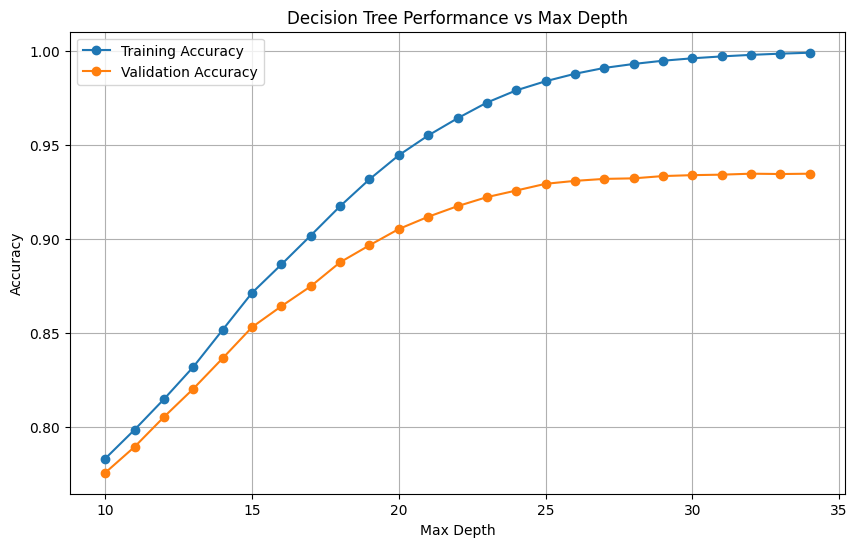

In [14]:
from sklearn.tree import DecisionTreeClassifier


max_depth_values = range(10, 35)  # you can adjust the range
train_accuracies = []
val_accuracies = []

for depth in max_depth_values:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    # Predictions
    y_train_pred = tree.predict(X_train)
    y_val_pred = tree.predict(X_val)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

# ========== Visualize ==========
plt.figure(figsize=(10,6))
plt.plot(max_depth_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(max_depth_values, val_accuracies, marker='o', label='Validation Accuracy')

plt.title('Decision Tree Performance vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

- Validation accuracy rises until roughly max_depth ≈ 20–25.
- After that, it stops improving — while training accuracy keeps increasing.
- So the optimal max_depth ≈ 20–25.

In [15]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=25,random_state=42)
tree.fit(X_train,y_train)

y_train_pred = tree.predict(X_train)
y_val_pred = tree.predict(X_val)

training_accuracy , validation_accuracy = accuracy_score(y_train_pred,y_train) , accuracy_score(y_val_pred,y_val)

print(f"Trainning Accuracy = {training_accuracy}")
print(f"Trainning Accuracy = {validation_accuracy}")


Trainning Accuracy = 0.9839934301759493
Trainning Accuracy = 0.9294336331925831


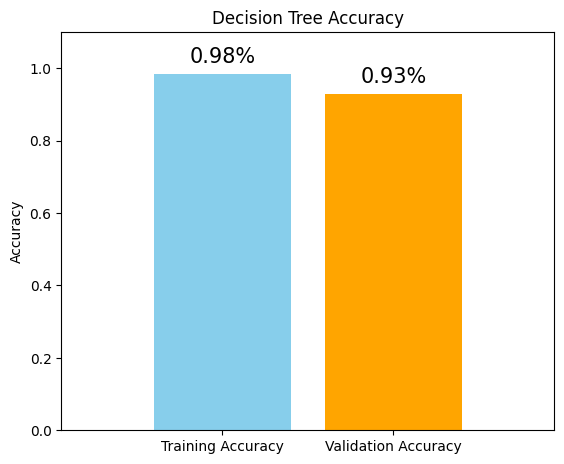

In [16]:
labels = ['Training Accuracy', 'Validation Accuracy']

accuracies = [training_accuracy,validation_accuracy]

plt.figure(figsize=(6, 5))
plt.bar(labels, accuracies, color=['skyblue', 'orange'])
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy')

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.03, f"{acc:.2f}%", ha='center', fontsize=15)


plt.ylim(0, 1.1)          # sets the limits of the y-axis in your plot (ymin , ymax).
plt.margins(x=0.3, y=0.3) # add internal space on sides and top
plt.tight_layout(pad=2.0) # add padding between figure and axes
plt.show()

## ❻ Random Forest Model

In [17]:
from sklearn.ensemble import RandomForestClassifier


# Define parameter values to try
n_estimators_list = [10,50,100,200]
max_depth_list = [2, 4, 8, 16, 32, 64, None]
min_samples_split_list = [2, 5, 10, 15, 20, 30, 50]                 




# default values
# n_estimators => 100
# criterion => 'gini'
# max_depth => None
# min_samples_split => 2

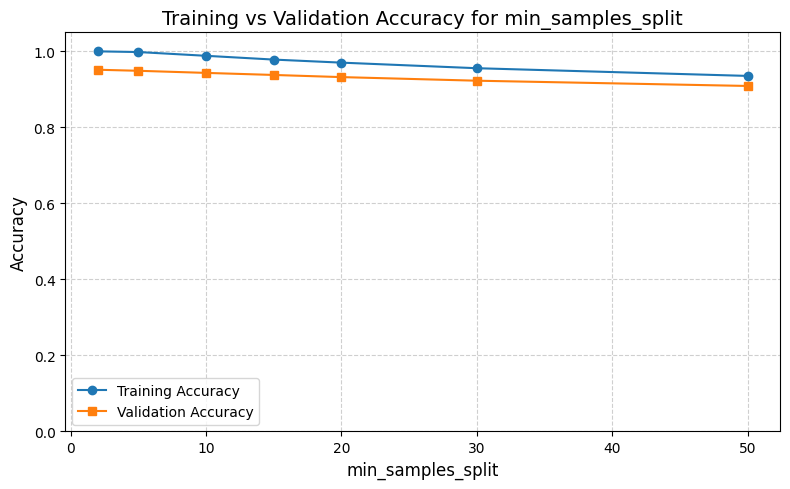

In [18]:
# Your existing data and list of values

accuracy_list_train = []
accuracy_list_val = []

for min_split in min_samples_split_list:
    
    # Train the model with the given min_samples_split
    model = RandomForestClassifier(
        min_samples_split=min_split,
        random_state=42
    )

    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Accuracy scores
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_val = accuracy_score(y_val, y_val_pred)
    
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

# --- Visualization ---
plt.figure(figsize=(8,5))
plt.plot(min_samples_split_list, accuracy_list_train, marker='o', label='Training Accuracy')
plt.plot(min_samples_split_list, accuracy_list_val, marker='s', label='Validation Accuracy')

plt.title('Training vs Validation Accuracy for min_samples_split', fontsize=14)
plt.xlabel('min_samples_split', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

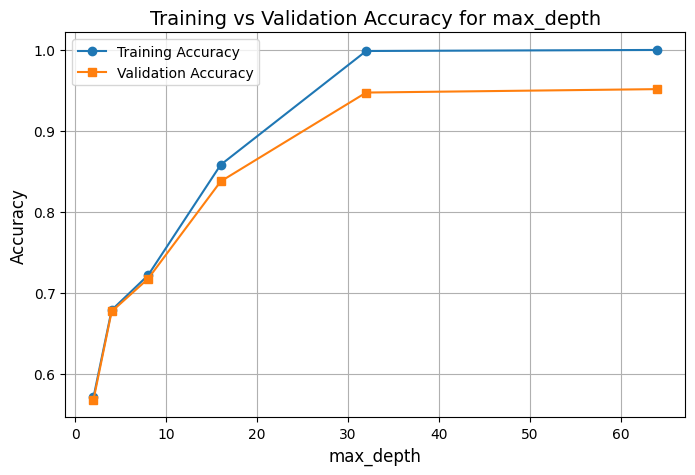

In [19]:
# Define your list of depths and random state
accuracy_list_train = []
accuracy_list_val = []

for depth in max_depth_list:
    
    # Train model with specific max_depth
    model = RandomForestClassifier(
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Accuracy scores (correct order)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_val = accuracy_score(y_val, y_val_pred)
    
    # Store accuracies
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

# --- Visualization ---
plt.figure(figsize=(8,5))
plt.plot(max_depth_list, accuracy_list_train, marker='o', label='Training Accuracy')
plt.plot(max_depth_list, accuracy_list_val, marker='s', label='Validation Accuracy')

plt.title('Training vs Validation Accuracy for max_depth', fontsize=14)
plt.xlabel('max_depth', fontsize=12)   # ✅ fixed here
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

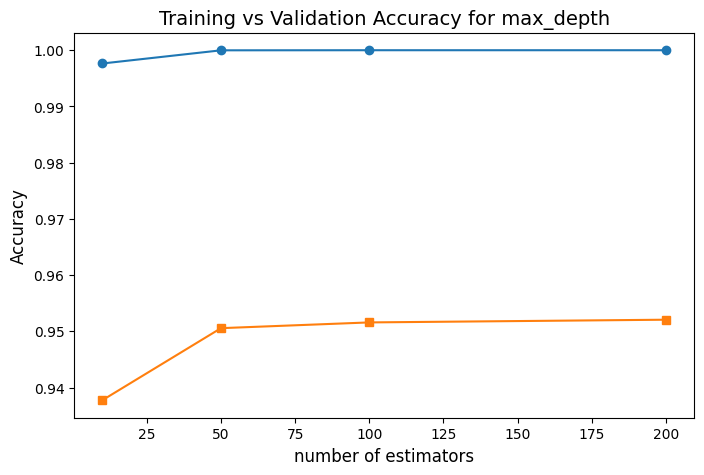

In [20]:
accuracy_list_train = []
accuracy_list_val = []

# Loop through each n_estimators value
for n_estimators in n_estimators_list:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Compute accuracies (✅ correct order)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_val = accuracy_score(y_val, y_val_pred)

    # Store results
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

# --- Visualization ---
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, accuracy_list_train, marker='o', label='Training Accuracy')
plt.plot(n_estimators_list, accuracy_list_val, marker='s', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy for max_depth', fontsize=14)
plt.xlabel('number of estimators', fontsize=12) 
plt.ylabel('Accuracy', fontsize=12) 
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=32,
    min_samples_split=2)

model.fit(X_train,y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

trainning_accuracy = accuracy_score(y_train,y_train_pred)
validation_accuracy = accuracy_score(y_val,y_val_pred)


print(f"Training Accuracy = {trainning_accuracy}")
print(f"Validation Accuracy = {validation_accuracy}")

Training Accuracy = 0.9990632099688228
Validation Accuracy = 0.9478956306223609


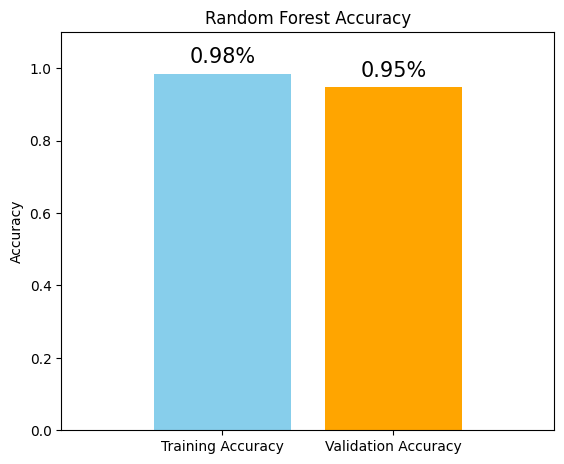

In [22]:
labels = ['Training Accuracy', 'Validation Accuracy']

accuracies = [training_accuracy,validation_accuracy]

plt.figure(figsize=(6, 5))
plt.bar(labels, accuracies, color=['skyblue', 'orange'])
plt.title('Random Forest Accuracy')
plt.ylabel('Accuracy')


for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.03, f"{acc:.2f}%", ha='center', fontsize=15)


plt.ylim(0, 1.1)          # sets the limits of the y-axis in your plot (ymin , ymax).
plt.margins(x=0.3, y=0.3) # add internal space on sides and top
plt.tight_layout(pad=2.0) # add padding between figure and axes
plt.show()

### ❼ XGBoost

In [9]:
from xgboost import XGBClassifier

n_estimators_list = [10,50,100,200,300,500,1000]
max_depth_list = [2, 4, 8, 16, 32, 64,128]
subsample_list = [0.1,0.2,0.3,0.4,0.5]
colsample_list = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_child_weight_list = [1, 2, 3, 4, 5, 6, 7,8,9,10,15,20]

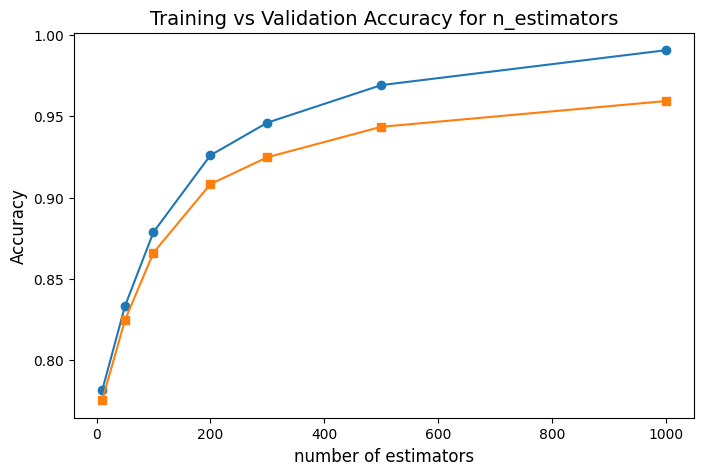

In [26]:
accuracy_list_train = []
accuracy_list_val = []

# ===== FIX LABELS TO START FROM 0 =====
y_train_fixed = y_train - y_train.min()
y_val_fixed = y_val - y_val.min()
y_min = y_train.min()  # store this to map back if needed


# Loop through each n_estimators value
for n_estimators in n_estimators_list:
    
    xgb_model = XGBClassifier(
    n_estimators=n_estimators,  # number of trees
    random_state=42,
    use_label_encoder=False,
    )
    
    # Use fixed labels for training
    xgb_model.fit(X_train, y_train_fixed)

    # ===== PREDICTIONS =====
    y_train_pred_fixed = xgb_model.predict(X_train)
    y_val_pred_fixed = xgb_model.predict(X_val)

    # Map predictions back to original labels
    y_train_pred = y_train_pred_fixed + y_min
    y_val_pred = y_val_pred_fixed + y_min

    # Compute accuracies (correct order)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_val = accuracy_score(y_val, y_val_pred)

    # Store results
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

# --- Visualization ---
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, accuracy_list_train, marker='o', label='Training Accuracy')
plt.plot(n_estimators_list, accuracy_list_val, marker='s', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy for n_estimators', fontsize=14)
plt.xlabel('number of estimators', fontsize=12) 
plt.ylabel('Accuracy', fontsize=12) 
plt.show()

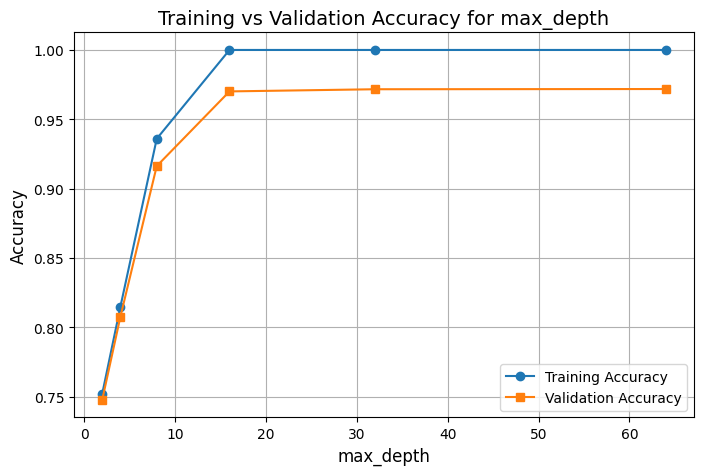

In [27]:
# Define your list of depths and random state
accuracy_list_train = []
accuracy_list_val = []

for depth in max_depth_list:
    
    xgb_model = XGBClassifier(
    max_depth = depth,
    random_state=42,
    use_label_encoder=False,
    )
    
    # Use fixed labels for training
    xgb_model.fit(X_train, y_train_fixed)

    # ===== PREDICTIONS =====
    y_train_pred_fixed = xgb_model.predict(X_train)
    y_val_pred_fixed = xgb_model.predict(X_val)

    # Map predictions back to original labels
    y_train_pred = y_train_pred_fixed + y_min
    y_val_pred = y_val_pred_fixed + y_min

    # Compute accuracies (correct order)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_val = accuracy_score(y_val, y_val_pred)

    # Store results
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

# --- Visualization ---
plt.figure(figsize=(8,5))
plt.plot(max_depth_list, accuracy_list_train, marker='o', label='Training Accuracy')
plt.plot(max_depth_list, accuracy_list_val, marker='s', label='Validation Accuracy')

plt.title('Training vs Validation Accuracy for max_depth', fontsize=14)
plt.xlabel('max_depth', fontsize=12)   # ✅ fixed here
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

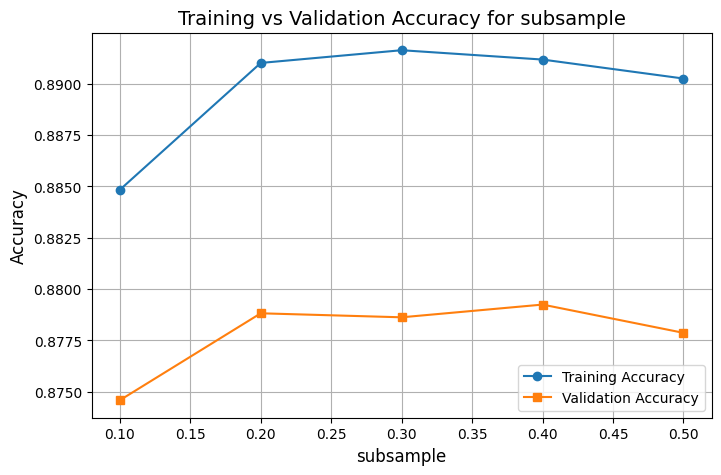

In [40]:
accuracy_list_train = []
accuracy_list_val = []

for subsample in subsample_list:
    
    xgb_model = XGBClassifier(
        subsample=subsample,
        random_state=42,
        use_label_encoder=False,
    )
    
    xgb_model.fit(X_train, y_train_fixed)

    y_train_pred_fixed = xgb_model.predict(X_train)
    y_val_pred_fixed = xgb_model.predict(X_val)

    y_train_pred = y_train_pred_fixed + y_min
    y_val_pred = y_val_pred_fixed + y_min

    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_val = accuracy_score(y_val, y_val_pred)

    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.figure(figsize=(8,5))
plt.plot(subsample_list, accuracy_list_train, marker='o', label='Training Accuracy')
plt.plot(subsample_list, accuracy_list_val, marker='s', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy for subsample', fontsize=14)
plt.xlabel('subsample', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


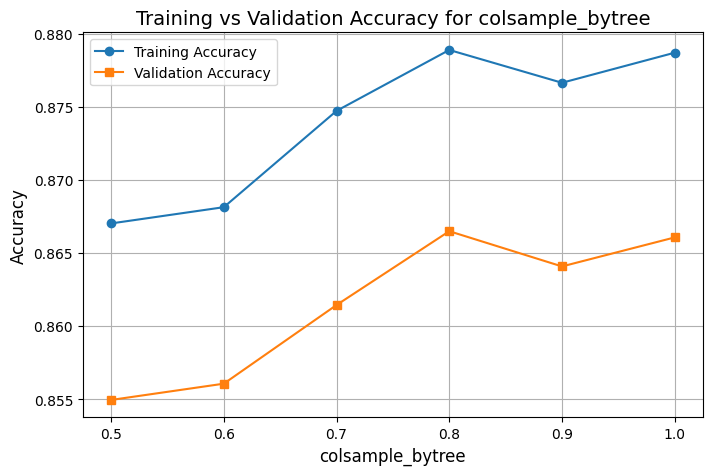

In [41]:
accuracy_list_train = []
accuracy_list_val = []

for colsample in colsample_list:
    
    xgb_model = XGBClassifier(
        colsample_bytree=colsample,
        random_state=42,
        use_label_encoder=False,
    )
    
    xgb_model.fit(X_train, y_train_fixed)

    y_train_pred_fixed = xgb_model.predict(X_train)
    y_val_pred_fixed = xgb_model.predict(X_val)

    y_train_pred = y_train_pred_fixed + y_min
    y_val_pred = y_val_pred_fixed + y_min

    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_val = accuracy_score(y_val, y_val_pred)

    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.figure(figsize=(8,5))
plt.plot(colsample_list, accuracy_list_train, marker='o', label='Training Accuracy')
plt.plot(colsample_list, accuracy_list_val, marker='s', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy for colsample_bytree', fontsize=14)
plt.xlabel('colsample_bytree', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


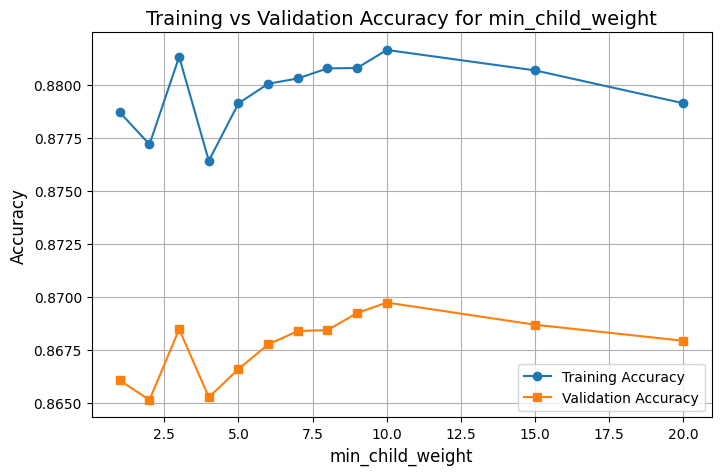

In [47]:
accuracy_list_train = []
accuracy_list_val = []

for child_weight in min_child_weight_list:
    
    xgb_model = XGBClassifier(
        min_child_weight=child_weight,
        random_state=42,
        use_label_encoder=False,
    )
    
    xgb_model.fit(X_train, y_train_fixed)

    y_train_pred_fixed = xgb_model.predict(X_train)
    y_val_pred_fixed = xgb_model.predict(X_val)

    y_train_pred = y_train_pred_fixed + y_min
    y_val_pred = y_val_pred_fixed + y_min

    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_val = accuracy_score(y_val, y_val_pred)

    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.figure(figsize=(8,5))
plt.plot(min_child_weight_list, accuracy_list_train, marker='o', label='Training Accuracy')
plt.plot(min_child_weight_list, accuracy_list_val, marker='s', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy for min_child_weight', fontsize=14)
plt.xlabel('min_child_weight', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


In [15]:
from xgboost import XGBClassifier

# ===== FIX LABELS TO START FROM 0 =====
y_train_fixed = y_train - y_train.min()
y_val_fixed = y_val - y_val.min()
y_min = y_train.min()  # store this to map back if needed

xgb_model = XGBClassifier(
        n_estimators = 1000,
        colsample_bytree = 0.8,
        subsample = 0.4,
        max_depth=16,
        min_child_weight=10,
        random_state=42,
        learning_rate=0.3,
        use_label_encoder=False,
    )
    
xgb_model.fit(X_train, y_train_fixed)

y_train_pred_fixed = xgb_model.predict(X_train)
y_val_pred_fixed = xgb_model.predict(X_val)

y_train_pred = y_train_pred_fixed + y_min
y_val_pred = y_val_pred_fixed + y_min

accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_val = accuracy_score(y_val, y_val_pred)

print(accuracy_train)
print(accuracy_val)

1.0
0.9637529832935561


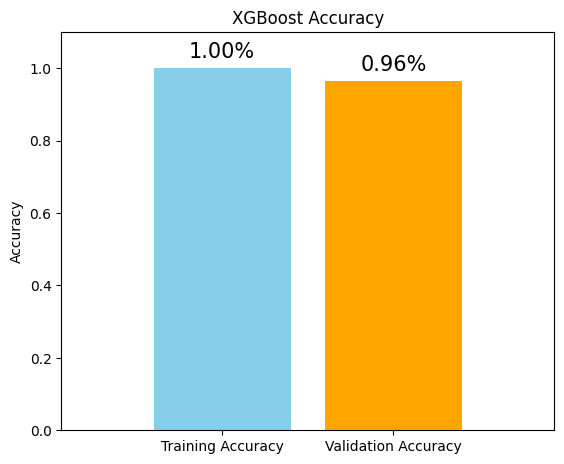

In [16]:
labels = ['Training Accuracy', 'Validation Accuracy']

accuracies = [accuracy_train,accuracy_val]

plt.figure(figsize=(6, 5))
plt.bar(labels, accuracies, color=['skyblue', 'orange'])
plt.title('XGBoost Accuracy')
plt.ylabel('Accuracy')


for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.03, f"{acc:.2f}%", ha='center', fontsize=15)


plt.ylim(0, 1.1)          # sets the limits of the y-axis in your plot (ymin , ymax).
plt.margins(x=0.3, y=0.3) # add internal space on sides and top
plt.tight_layout(pad=2.0) # add padding between figure and axes
plt.show()

In [19]:
from sklearn.metrics import  confusion_matrix, classification_report

# Shift test labels using the same offset from training
y_test_fixed = y_test - y_min

# Predict (these predictions are in the shifted label space)
y_test_pred_fixed = xgb_model.predict(X_test)

# Convert predictions back to original labels
y_test_pred = y_test_pred_fixed + y_min

# Ensure integer type before evaluation
y_test_pred = y_test_pred.astype(int)
y_test = y_test.astype(int)

testing_accuracy = accuracy_score(y_test, y_test_pred)

# Evaluate
print("Test Accuracy:", testing_accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Test Accuracy: 0.9625596658711217

Classification Report:
               precision    recall  f1-score   support

           1       0.97      0.96      0.96     31659
           2       0.97      0.97      0.97     42664
           3       0.96      0.96      0.96      5297
           4       0.90      0.85      0.87       394
           5       0.91      0.85      0.88      1493
           6       0.92      0.93      0.93      2591
           7       0.97      0.96      0.96      3054

    accuracy                           0.96     87152
   macro avg       0.94      0.93      0.93     87152
weighted avg       0.96      0.96      0.96     87152



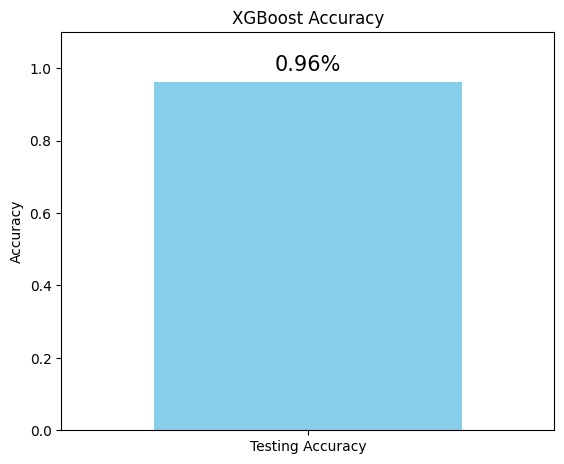

In [24]:
labels = ['Testing Accuracy']

accuracies = [testing_accuracy]

plt.figure(figsize=(6, 5))
plt.bar(labels, accuracies, color='skyblue')
plt.title('XGBoost Accuracy')
plt.ylabel('Accuracy')


for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.03, f"{acc:.2f}%", ha='center', fontsize=15)


plt.ylim(0, 1.1)          # sets the limits of the y-axis in your plot (ymin , ymax).
plt.margins(x=0.3, y=0.3) # add internal space on sides and top
plt.tight_layout(pad=2.0) # add padding between figure and axes
plt.show()

### ❽ Saving Best Model

In [25]:
import joblib

joblib.dump(xgb_model,"xgb_best_model.pkl")

['xgb_best_model.pkl']